In [1]:
import pandas as pd

files = [
    "./data/번개장터_공기청정기.csv",
    "./data/번개장터_바운서.csv",
    "./data/번개장터_분유포트.csv",
    "./data/번개장터_젖병소독기.csv"
]

dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

df_bunjang = pd.concat(dfs, ignore_index=True)
df_bunjang

,상품명,가격
0,삼성 공기청정기,"1,200,000"
1,벤소닉 공기청정기~ 택포,"12,000"
2,삼성대형공기청정기 특가판매 2대,"590,000"
3,# 삼성 비스포크 큐브 에어 펫케어 공기청정기 공기청정 공청기,"150,000"
4,NANODRON 공기청정기 골드,"2,000,000"
...,...,...
849,델리팬 젖병소독기 (새상품),"95,000"
850,에디슨 젖병 스팀 소독 건조기 2.5세댜,"70,000"
851,폴레드 픽셀 젖병 살균기 + 트레이 세트,"180,000"
852,필립스 아벤트 소독기,"52,000"


In [2]:
import pandas as pd
import numpy as np

# 💡 마스터님을 위한 데이터 전처리 및 카테고리 라벨링 함수
def preprocess_and_categorize(df, keywords):
    print("마스터의 명에 따라 가격 정제 및 카테고리 분류를 시작합니다.")
    
    # 1. 원본 훼손을 막기 위해 복사본을 만들어 작업합니다.
    df_clean = df.copy()
    
    # 2. 가격 데이터 정제
    df_clean['가격'] = df_clean['가격'].astype(str).str.replace(r'[^0-9]', '', regex=True)
    df_clean = df_clean[df_clean['가격'] != '']
    df_clean['가격'] = df_clean['가격'].astype(int)

    # 🔹 추가: 상품명 공백 제거 버전 생성
    df_clean['상품명_공백제거'] = df_clean['상품명'].astype(str).str.replace(r'\s+', '', regex=True)
    
    # 3. 카테고리 기본값
    df_clean['카테고리'] = '미분류'
    
    for kw in keywords:
        df_clean.loc[df_clean['상품명'].str.contains(kw, na=False), '카테고리'] = kw

    # 🔹 추가: 공백 제거 상품명으로도 분류
    for kw in keywords:
        df_clean.loc[df_clean['상품명_공백제거'].str.contains(kw, na=False), '카테고리'] = kw

    # 🔹 추가: 미분류 데이터 삭제
    df_clean = df_clean[df_clean['카테고리'] != '미분류']
        
    # 인덱스 재정렬
    df_clean.reset_index(drop=True, inplace=True)
    
    print(f"전처리 완료! 불순물이 제거되고 총 {len(df_clean)}개의 알짜배기 데이터가 남았습니다.\n")
    return df_clean

In [5]:
# 우리가 분류할 4개의 절대 키워드
my_keywords = ['공기청정기', '바운서', '분유포트', '젖병소독기']

# 이전 단계에서 만든 df_naver, df_coupang을 전처리 함수에 넣고 돌립니다.
print("--- [번개장터 데이터 전처리] ---")
df_bunjang_clean = preprocess_and_categorize(df_bunjang, my_keywords)

# (확인용) 쿠팡 데이터의 상위 5개를 출력하여 '카테고리' 열과 정수형 '가격'을 확인합니다.
df_bunjang_clean.head()

--- [번개장터 데이터 전처리] ---
마스터의 명에 따라 가격 정제 및 카테고리 분류를 시작합니다.
전처리 완료! 불순물이 제거되고 총 781개의 알짜배기 데이터가 남았습니다.



,상품명,가격,상품명_공백제거,카테고리
0,삼성 공기청정기,1200000,삼성공기청정기,공기청정기
1,벤소닉 공기청정기~ 택포,12000,벤소닉공기청정기~택포,공기청정기
2,삼성대형공기청정기 특가판매 2대,590000,삼성대형공기청정기특가판매2대,공기청정기
3,# 삼성 비스포크 큐브 에어 펫케어 공기청정기 공기청정 공청기,150000,#삼성비스포크큐브에어펫케어공기청정기공기청정공청기,공기청정기
4,NANODRON 공기청정기 골드,2000000,NANODRON공기청정기골드,공기청정기



📊 [번개장터] 카테고리별 평균 가격 📊
 - 공기청정기: 173,326원
 - 바운서: 139,342원
 - 분유포트: 56,479원
 - 젖병소독기: 79,268원


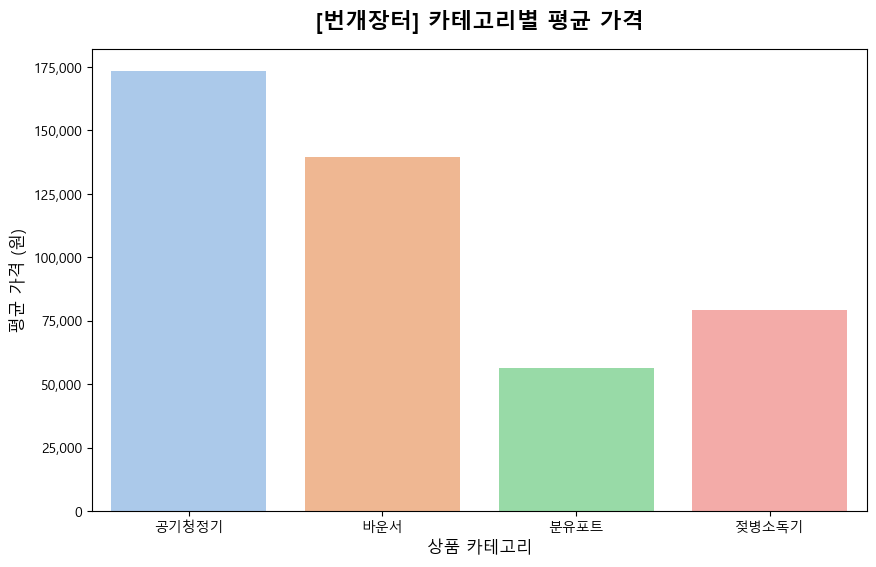

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter

# 💡 장인의 방어막: 눈에 거슬리는 빨간 경고창(FutureWarning 등)을 원천 차단합니다.
warnings.filterwarnings('ignore')

# 폰트 세팅 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def print_and_plot_average_price(df, platform_name):
    # ---------------------------------------------------------
    # 1. 텍스트로 평균값 먼저 깔끔하게 보고하기
    # ---------------------------------------------------------
    # 카테고리별로 그룹을 묶어(groupby) 가격의 평균(mean)을 구하고, 소수점을 버립니다(int).
    avg_prices = df.groupby('카테고리')['가격'].mean().astype(int)
    
    print(f"\n📊 [{platform_name}] 카테고리별 평균 가격 📊")
    for cat, price in avg_prices.items():
        # 천 단위마다 쉼표(,)를 찍어서 보기 좋게 출력합니다.
        print(f" - {cat}: {price:,}원")
        
    # ---------------------------------------------------------
    # 2. 직관적인 막대그래프(Bar Chart) 그리기
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    
    # errorbar=None : 막대기 위에 생기는 검은색 선(오차범위)을 없애고 순수 평균 높이만 보여줍니다.
    # hue='카테고리', legend=False : 이전 버전의 경고창을 없애는 핵심 마법입니다.
    sns.barplot(data=df, x='카테고리', y='가격', hue='카테고리', legend=False, palette='pastel', errorbar=None)
    
    plt.title(f'[{platform_name}] 카테고리별 평균 가격', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('상품 카테고리', fontsize=12)
    plt.ylabel('평균 가격 (원)', fontsize=12)
    
    # 💡 장인의 디테일: y축 숫자가 1e6(과학적 표기법)으로 깨지지 않도록 천 단위 쉼표가 들어간 숫자로 바꿉니다.
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
    
    plt.show()

# ==========================================
# 🚀 함수 실행 부분
# ==========================================
print_and_plot_average_price(df_bunjang_clean, '번개장터')

In [7]:
df.to_csv('./data/쿠팡_젖병소독기.csv', index=False, encoding='utf-8-sig')

,상품명,가격,상품명_공백제거,카테고리


In [9]:
df_bunjang_clean.to_csv('./data/번개장터_카테고리분류.csv', index=False, encoding='utf-8-sig')